Writing this on 8/10/2025


In [1]:
import torch
import torch.autograd as autograd         # computation graph
from torch import Tensor                  # tensor node in the computation graph
import torch.nn as nn                     # neural networks
import torch.optim as optim               # optimizers e.g. gradient descent, ADAM, etc.
from torch.nn.parameter import Parameter

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.ticker


import numpy as np
import time
# from pyDOE import lhs         #Latin Hypercube Sampling
import scipy.io

from smt.sampling_methods import LHS
from scipy.io import loadmat,savemat


In [12]:
vPINN_hist = loadmat('AFSD_NN_64.mat')['train_loss'].reshape(-1,1)
coPINN_hist = loadmat('./coPINN_comparison/ASFD_coPINN.mat')['train_loss'].reshape(-1,1)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


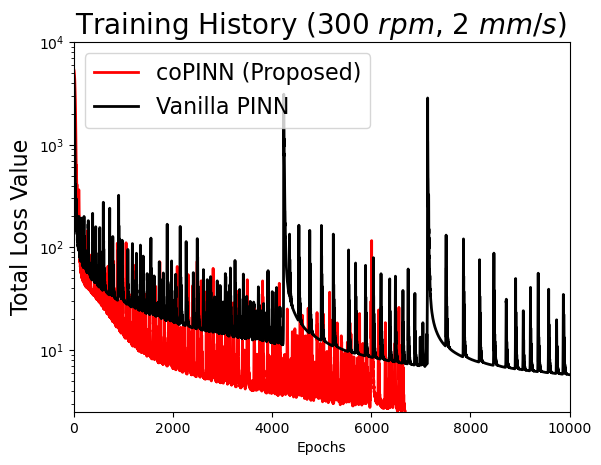

In [31]:
fig,ax = plt.subplots()

ax.plot(coPINN_hist,'r',label = 'coPINN (Proposed)',linewidth = 2)
ax.plot(vPINN_hist,'k',label = 'Vanilla PINN',linewidth = 2)

ax.set_xlabel('Epochs')
ax.set_ylabel('Total Loss Value',math_fontfamily = 'cm',fontsize = 16)
ax.set_title('Training History (300 $rpm$, 2 $mm/s$) ',fontsize = 20)
ax.legend(loc = 2,fontsize = 16)

ax.set_xlim([0,10000])
ax.set_ylim([2.5,10000])
ax.set_yscale('log')

formats = ['pdf','svg','png','eps']

for format in formats:
    folder = './Plots/'+format + '/'
    fig.savefig(folder+'Train_hist.'+format,format = format,bbox_inches = 'tight')

In [34]:
coPINN_hist.shape

(6686, 1)